In [27]:
!kaggle datasets download -d snap/amazon-fine-food-reviews --unzip


'latin-1' codec can't encode characters in position 0-1: ordinal not in range(256)


In [28]:
# 아마존 리뷰 데이터 셋 다운로드
# https://www.kaggle.com/snap/amazon‑fine‑food‑reviews
!pip install kaggle

In [29]:
import os
os.environ['KAGGLE_USERNAME'] = '본인_유저네임'
os.environ['KAGGLE_KEY'] = '본인_API_키'
import kaggle

In [30]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import urllib.request
np.random.seed(seed=0)


In [31]:
# Reviews.csv 파일을 데이터프레임에 저장  ,
# 단 10만개 행으로 제한
data = pd.read_csv("Reviews.csv", nrows = 100000) 
print('전 체   리 뷰   개 수  :',(len(data)))

전 체   리 뷰   개 수  : 100000


In [32]:
# 상위 5개 샘플 출력
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [33]:
# Text(리뷰)와 Summary(요약) 컬럼만 남기기
data = data[['Text','Summary']] 
data.head()

,Text,Summary
0,I have bought several of the Vitality canned d...,Good Quality Dog Food
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised
2,This is a confection that has been around a fe...,"""Delight"" says it all"
3,If you are looking for the secret ingredient i...,Cough Medicine
4,Great taffy at a great price. There was a wid...,Great taffy


In [34]:
# 랜덤으로 샘플 10개 출력 
data.sample(10)

,Text,Summary
3582,"I rarely eat anything but whole wheat pasta, b...",reminds me of Italy
60498,I absolutely love 5-hour ENERGY! I use it afte...,5-hour ENERGY Highly Recommend!
53227,"this chocolate is a true treat to eat, perfect...",supreme chocolate
21333,Greenies are very muched loved as a tatsy Trea...,Excellent Teeth Cleaner
3885,I love these noodles. They are really great f...,Great and good price!
51521,These are great! As a lover of all chips I'm s...,"Delicious, just like Salt and Vinegar Chips!"
84261,Like other customers I divide these into handf...,"Great snack, great value"
10685,I recommend this instead for the same price: <...,"It's ok, but certainly not worth the cost"
59948,"The noodles were all very broken, but the tast...",Knorr's beef noodles
41032,"Despite claiming they use the ""finest ingredie...",HORRIBLE INGREDIENTS


# 데이터 정제

In [35]:
# 중복 샘플 있는지 확인
print('Text열에서 중복을 배제한 유일한 샘플의 수 :', data['Text'].nunique())
print('Summary열에서 중복을 배제한 유일한 샘플의 수 :', data['Summary'].nunique()
)

Text열에서 중복을 배제한 유일한 샘플의 수 : 88426
Summary열에서 중복을 배제한 유일한 샘플의 수 : 72348


In [36]:
# Null 샘플 확인
print(data.isnull().sum())

Text       0
Summary    2
dtype: int64


In [37]:
# Summary Null샘플 2 확인 , 제거
data.dropna(axis=0, inplace=True) 
print('전 체   샘 플 수  :',(len(data)))

전 체   샘 플 수  : 99998


In [38]:
# 축약어 사전 만들기
# https://stackoverflow.com/questions/19790188/expanding‑english‑language‑contractions‑in‑ python

# Source - https://stackoverflow.com/a/19794953
# Posted by arturomp, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-14, License - CC BY-SA 3.0

contractions = { 
"ain't": "am not / are not / is not / has not / have not",
"aren't": "are not / am not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he had / he would",
"he'd've": "he would have",
"he'll": "he shall / he will",
"he'll've": "he shall have / he will have",
"he's": "he has / he is",
"how'd": "how did",
"how'd'y": "how do you",
"how'll": "how will",
"how's": "how has / how is / how does",
"I'd": "I had / I would",
"I'd've": "I would have",
"I'll": "I shall / I will",
"I'll've": "I shall have / I will have",
"I'm": "I am",
"I've": "I have",
"isn't": "is not",
"it'd": "it had / it would",
"it'd've": "it would have",
"it'll": "it shall / it will",
"it'll've": "it shall have / it will have",
"it's": "it has / it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"mightn't've": "might not have",
"must've": "must have",
"mustn't": "must not",
"mustn't've": "must not have",
"needn't": "need not",
"needn't've": "need not have",
"o'clock": "of the clock",
"oughtn't": "ought not",
"oughtn't've": "ought not have",
"shan't": "shall not",
"sha'n't": "shall not",
"shan't've": "shall not have",
"she'd": "she had / she would",
"she'd've": "she would have",
"she'll": "she shall / she will",
"she'll've": "she shall have / she will have",
"she's": "she has / she is",
"should've": "should have",
"shouldn't": "should not",
"shouldn't've": "should not have",
"so've": "so have",
"so's": "so as / so is",
"that'd": "that would / that had",
"that'd've": "that would have",
"that's": "that has / that is",
"there'd": "there had / there would",
"there'd've": "there would have",
"there's": "there has / there is",
"they'd": "they had / they would",
"they'd've": "they would have",
"they'll": "they shall / they will",
"they'll've": "they shall have / they will have",
"they're": "they are",
"they've": "they have",
"to've": "to have",
"wasn't": "was not",
"we'd": "we had / we would",
"we'd've": "we would have",
"we'll": "we will",
"we'll've": "we will have",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what shall / what will",
"what'll've": "what shall have / what will have",
"what're": "what are",
"what's": "what has / what is",
"what've": "what have",
"when's": "when has / when is",
"when've": "when have",
"where'd": "where did",
"where's": "where has / where is",
"where've": "where have",
"who'll": "who shall / who will",
"who'll've": "who shall have / who will have",
"who's": "who has / who is",
"who've": "who have",
"why's": "why has / why is",
"why've": "why have",
"will've": "will have",
"won't": "will not",
"won't've": "will not have",
"would've": "would have",
"wouldn't": "would not",
"wouldn't've": "would not have",
"y'all": "you all",
"y'all'd": "you all would",
"y'all'd've": "you all would have",
"y'all're": "you all are",
"y'all've": "you all have",
"you'd": "you had / you would",
"you'd've": "you would have",
"you'll": "you shall / you will",
"you'll've": "you shall have / you will have",
"you're": "you are",
"you've": "you have"
}


In [39]:
# NLTK의 불용어
stop_words = set(stopwords.words('english')) 
print('불용어 개수:', len(stop_words)) 
print(stop_words)

불용어 개수: 198
{'very', 'same', 'from', 'both', 'off', 'but', 'my', 'those', 'itself', 'over', 'while', 'mustn', 'after', 'there', 'own', 'yours', "hasn't", 'not', "i'd", "needn't", "aren't", 'of', 'whom', "you'd", "she's", 'these', 'am', 'again', 'about', 'isn', 'do', 'himself', 'each', 'against', "i'm", "wouldn't", 'our', 'won', 'shan', 'aren', "we'd", 'between', 'o', 'and', 'her', 'she', 'has', 'me', 'hadn', 'only', 're', "didn't", 'ma', 'be', 'can', 'will', 'more', 'what', 'on', 'because', 'haven', 'll', 'why', 'further', 'under', 'above', 'a', 'below', 'until', "mustn't", 'mightn', 'myself', 'is', 'here', 'should', 'doing', 'wouldn', 'shouldn', 'all', 'you', 'once', "shan't", 'some', "he'll", "she'd", 'for', "it's", 'are', 'that', 'ain', 's', 'then', "shouldn't", 'the', 'an', 'themselves', "it'd", "mightn't", "won't", 'as', 'no', 'so', 'theirs', "wasn't", 'yourself', 'ourselves', 'any', "haven't", "they'll", 'than', 'being', 'your', 'didn', 'hers', "i'll", 'now', "weren't", 'if', 'th

In [40]:
# 전처리 함수 설계
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()  # 소문자화
    sentence = BeautifulSoup(sentence, "lxml").text  # HTML 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence)  # 괄호 문자열 제거 Ex) my husband (and myself) → my husband
    sentence = re.sub('"', '', sentence)  # 쌍따옴표 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")])  # 축약어 정규화
    sentence = re.sub(r"'s\b", "", sentence)  # 소유격 제거 Ex) roland's → roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence)  # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence)  # m이 3개 이상이면 2개로 변경 Ex) ummmmmmm → umm

    if remove_stopwords:
        # 불용어 제거 (Text용)
        tokens = ' '.join(word for word in sentence.split() if not word in stop_words if len(word) > 1)
    else:
        # 불용어 미제거 (Summary용)
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)

    return tokens


In [41]:
# preprocess_sentence 함수가 잘 작동하는지 확인 
# 불용어 제거
temp_text = 'Everything I bought was great, infact I ordered twice and the third ordered was<br />for my mother and father.'
# 불용어 제거 x
temp_summary = 'Great way to start (or finish) the day!!!' 
print(preprocess_sentence(temp_text))
print(preprocess_sentence(temp_summary, 0))

everything bought great infact ordered twice third ordered wasfor mother father
great way to start the day


In [42]:
# Text 열 전처리
clean_text = []

for s in data['Text']:
    clean_text.append(preprocess_sentence(s))

clean_text[:5]

['bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better',
 'product arrived labeled jumbo salted peanuts peanuts actually small sized unsalted sure error vendor intended represent product jumbo',
 'confection around centuries light pillowy citrus gelatin nuts case filberts cut tiny squares liberally coated powdered sugar tiny mouthful heaven chewy flavorful highly recommend yummy treat familiar story lewis lion witch wardrobe treat seduces edmund selling brother sisters witch',
 'looking secret ingredient robitussin believe found got addition root beer extract ordered made cherry soda flavor medicinal',
 'great taffy great price wide assortment yummy taffy delivery quick taffy lover deal']

In [43]:
# Summary 열 전처리
clean_summary = []

for s in data['Summary']:
    clean_summary.append(preprocess_sentence(s, 0))

clean_summary[:5]

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26980\2596949755.py:4: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  sentence = BeautifulSoup(sentence, "lxml").text  # HTML 태그 제거


['good quality dog food',
 'not as advertised',
 'delight says it all',
 'cough medicine',
 'great taffy']

In [44]:
# 전처리 후 결과 데이터프레임에 저장 
data['Text'] = clean_text
data['Summary'] = clean_summary

In [45]:
# 전처리 결과에서 빈 값이 생겼을 경우, 
# Null로 변경 후 Null로 된 데이터 있는지 확인하기
data.replace('', np.nan, inplace=True) 
print(data.isnull().sum())

Text        0
Summary    81
dtype: int64


In [46]:
# 81개 null 값 제거 후 확인
data.dropna(axis = 0, inplace = True) 
print('전체 샘플 수  :',(len(data)))

전체 샘플 수  : 99917


텍 스 트 의   최 소   길 이  : 2
텍 스 트 의   최 대   길 이  : 1235
텍 스 트 의   평 균   길 이  : 38.69761902378975
요 약 의   최 소   길 이  : 1
요 약 의   최 대   길 이  : 28
요 약 의   평 균   길 이  : 4.032066615290692


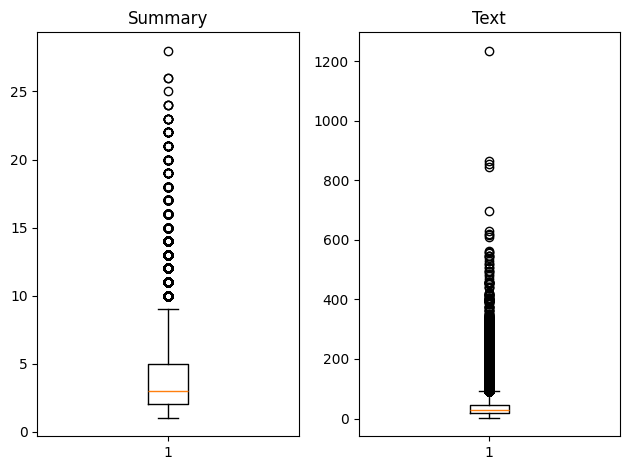

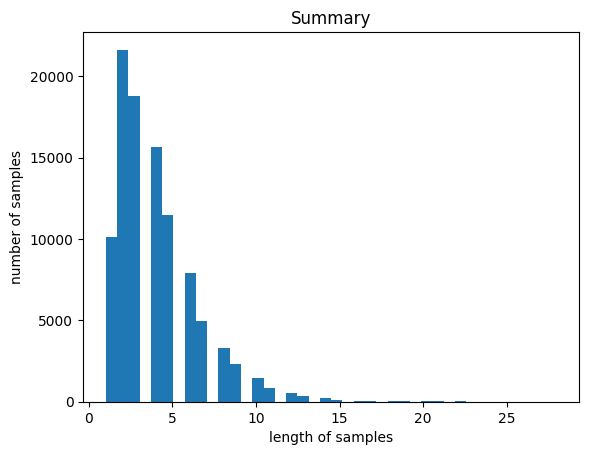

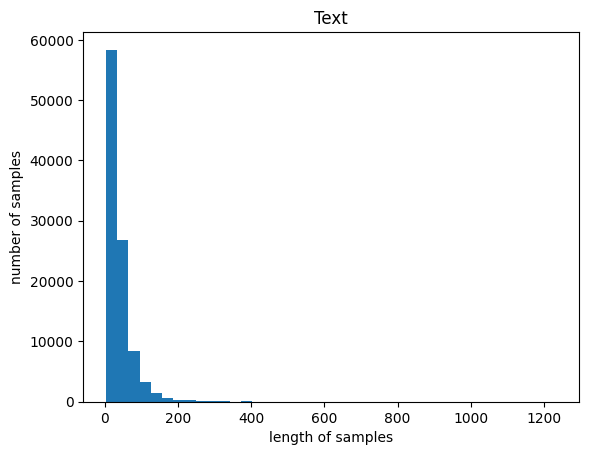

In [47]:
# 길이 분포 출력 
text_len = [len(s.split()) for s in data['Text']]
summary_len = [len(s.split()) for s in data['Summary']]

print('텍 스 트 의   최 소   길 이  : {}'.format(np.min(text_len)))
print('텍 스 트 의   최 대   길 이  : {}'.format(np.max(text_len)))
print('텍 스 트 의   평 균   길 이  : {}'.format(np.mean(text_len)))
print('요 약 의   최 소   길 이  : {}'.format(np.min(summary_len)))
print('요 약 의   최 대   길 이  : {}'.format(np.max(summary_len)))
print('요 약 의   평 균   길 이  : {}'.format(np.mean(summary_len)))

plt.subplot(1,2,1)
plt.boxplot(summary_len)
plt.title('Summary')

plt.subplot(1,2,2)
plt.boxplot(text_len)
plt.title('Text')

plt.tight_layout()
plt.show()

plt.title('Summary')
plt.hist(summary_len, bins=40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('Text')
plt.hist(text_len, bins=40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

Text (원문)
최소: 2
최대: 1235
평균: 38.7
평균 38 보다 크게 잡기 > 50

Summary (요약)
최소: 1
최대: 28
평균: 4.03
평균 4보다 크게 잡기 > 8
(통상적으로 평균 * 2 정도 잡음)

In [48]:
text_max_len = 50 
summary_max_len = 8

In [49]:
# 50 과 8 , 두 길이가 얼마나 많은 샘플길이 보다 큰지 확인
def below_threshold_len(max_len, nested_list):
    cnt = 0

    for s in nested_list:
        if (len(s.split()) <= max_len):
            cnt = cnt + 1

    print('전체 샘플 중 길이가 %s 이하인 샘플의 비율 : %s' % (max_len, (cnt / len(nested_list))))

In [50]:
# text 열 길이 (50 이하 비율 약 77%)
below_threshold_len(text_max_len, data['Text'])

전체 샘플 중 길이가 50 이하인 샘플의 비율 : 0.7773251798993165


In [51]:
# summary 열 길이 (8 이하인 경우 약 94%)
below_threshold_len(summary_max_len, data['Summary'])

전체 샘플 중 길이가 8 이하인 샘플의 비율 : 0.9395498263558754


In [52]:
# 줄어든 샘플 수 확인
data = data[data['Text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['Summary'].apply(lambda x: len(x.split()) <= summary_max_len)]
print('전체 샘플 수  :',(len(data)))

전체 샘플 수  : 74562


In [53]:
# 정제 완료된 상위 5개 샘플 출력
data.head()

,Text,Summary
0,bought several vitality canned dog food produc...,good quality dog food
1,product arrived labeled jumbo salted peanuts p...,not as advertised
2,confection around centuries light pillowy citr...,delight says it all
3,looking secret ingredient robitussin believe f...,cough medicine
4,great taffy great price wide assortment yummy ...,great taffy


# Seq2Seq 훈련 시작

In [54]:
# 요약 데이터에는 시작(레이블,sostoken)과 
# 종료(디코더,eostoken) 토큰을 추가해야함.
data['decoder_input'] = data['Summary'].apply(lambda x : 'sostoken '+ x)
data['decoder_target'] = data['Summary'].apply(lambda x : x + ' eostoken')
data.head()


,Text,Summary,decoder_input,decoder_target
0,bought several vitality canned dog food produc...,good quality dog food,sostoken good quality dog food,good quality dog food eostoken
1,product arrived labeled jumbo salted peanuts p...,not as advertised,sostoken not as advertised,not as advertised eostoken
2,confection around centuries light pillowy citr...,delight says it all,sostoken delight says it all,delight says it all eostoken
3,looking secret ingredient robitussin believe f...,cough medicine,sostoken cough medicine,cough medicine eostoken
4,great taffy great price wide assortment yummy ...,great taffy,sostoken great taffy,great taffy eostoken


In [55]:
# 인코더 의 입력 / 디코더 입력, 레이블 저장
encoder_input = np.array(data['Text'])
decoder_input = np.array(data['decoder_input'])
decoder_target = np.array(data['decoder_target'])

# 데이터 분리
훈련데이터, 테스트 데이터 분리

In [56]:
# 순서가 섞인 정수 시퀀스 만들기
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)
print(indices)


[ 9219 57202 29781 ... 45440 26023  1298]


In [57]:
# 나온 정수 시퀀스를 샘플 순서로 정의 (샘플들이 섞이게 됨)
encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

In [58]:
# 섞인 데이터를 8:2 비율로 훈련,테스트 데이터로 분리
n_of_val = int(len(encoder_input)*0.2)

print('테스트 데이터 의 수 :',n_of_val)


테스트 데이터 의 수 : 14912


In [59]:
encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:] 
decoder_target_test = decoder_target[-n_of_val:]

In [60]:
print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

훈련 데이터의 개수 : 59650
훈련 레이블의 개수 : 59650
테스트 데이터의 개수 : 14912
테스트 레이블의 개수 : 14912


# 정수 인코딩 
텍스트 숫자처리를 위해 훈련,테스트 데이터 정수 인코딩 수행

In [61]:
# 단어집합 vocaburary 만들기
src_tokenizer = Tokenizer()
# 원문 encoder_input_train
src_tokenizer.fit_on_texts(encoder_input_train)

In [62]:
# 7번 미만 등장단어(희귀 단어)
threshold = 7

total_cnt = len(src_tokenizer.word_index)  # 단어의 수
rare_cnt = 0  # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0  # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0  # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in src_tokenizer.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수 : %s' % (threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s' % (total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율 :", (rare_cnt / total_cnt) * 100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율 :", (rare_freq / total_freq) * 100)

단어 집합(vocabulary)의 크기 : 32295
등장 빈도가 6번 이하인 희귀 단어의 수 : 23566
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 8729
단어 집합에서 희귀 단어의 비율 : 72.9710481498684
전체 등장 빈도에서 희귀 단어 등장 빈도 비율 : 3.089437125080993


In [63]:
# 단어 사전(vocabulary) 크기 정하기
# 빈도수 높은 8000개 단어만 사용
# 전체 단어를 다 사용하면 메모리가 커지고 학습 속도가 느려질 수 있음
src_vocab = 8000

# 단어 → 숫자 변환을 위한 토크나이저 생성
src_tokenizer = Tokenizer(num_words=src_vocab)

# 훈련 데이터로 단어 사전 생성
src_tokenizer.fit_on_texts(encoder_input_train)

# 텍스트 시퀀스를 정수 시퀀스로 변환
encoder_input_train = src_tokenizer.texts_to_sequences(encoder_input_train)
encoder_input_test = src_tokenizer.texts_to_sequences(encoder_input_test)

In [64]:
# 정수 인코딩 잘 되었는지 확인. 3개 샘플 출력 
print(encoder_input_train[:3])

[[147, 3, 120, 187, 146, 4148, 1775, 57], [701, 10, 49, 1093, 41, 74, 21, 58, 1471, 22, 160, 136, 512, 1196, 60, 49, 236, 14, 693, 56, 107, 49, 43, 282, 176, 3, 321, 1083, 11, 487, 510, 43, 993], [362, 16, 3, 2550, 338, 149, 1594, 824, 2124, 9, 879]]


In [65]:
# 레이블 요약 데이터 도 수행 
tar_tokenizer = Tokenizer()
tar_tokenizer.fit_on_texts(decoder_input_train)

In [66]:
# 6번 미만 등장 = 희귀단어
# 1~ 6 희귀단어 / 6 ~정상단어
threshold = 6

total_cnt = len(tar_tokenizer.word_index)  # 단어의 수
rare_cnt = 0  # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0  # 훈련 데이터의 전체 단어 빈도수 총합
rare_freq = 0  # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수 총합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tar_tokenizer.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if (value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수 : %s' % (threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s' % (total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율 :", (rare_cnt / total_cnt) * 100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율 :", (rare_freq / total_freq) * 100)

단어 집합(vocabulary)의 크기 : 10572
등장 빈도가 5번 이하인 희귀 단어의 수 : 8008
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 2564
단어 집합에서 희귀 단어의 비율 : 75.74725690503216
전체 등장 빈도에서 희귀 단어 등장 빈도 비율 : 5.332213668523486


In [67]:
tar_vocab = 2000

tar_tokenizer = Tokenizer(num_words=tar_vocab)

tar_tokenizer.fit_on_texts(decoder_input_train)
tar_tokenizer.fit_on_texts(decoder_target_train)

In [68]:
# 텍스트 시퀀스를 정수 시퀀스로 변환
decoder_input_train = tar_tokenizer.texts_to_sequences(decoder_input_train)
decoder_target_train = tar_tokenizer.texts_to_sequences(decoder_target_train)
decoder_input_test = tar_tokenizer.texts_to_sequences(decoder_input_test)
decoder_target_test = tar_tokenizer.texts_to_sequences(decoder_target_test)

In [69]:
# 정수인코딩 확인, 훈련데이터 앞 5개 샘플 , 
# seq2seq 구조 : decoder_input 과 decoder_target 이 한 칸 밀린 형태
# decoder_input : 시작 토큰 <sostoken>이 포함 됨.
print(decoder_input_train[:5])

[[1, 40, 4], [1, 15, 13, 178, 78, 40, 102], [1, 130, 365, 6, 1574], [1, 3, 17, 603, 473, 353], [1, 106, 148]]


In [70]:
# decoder_target :종료 토큰  <eostoken> 포함
print(decoder_target_train[:5])

[[40, 4, 2], [15, 13, 178, 78, 40, 102, 2], [130, 365, 6, 1574, 2], [3, 17, 603, 473, 353, 2], [106, 148, 2]]


# 빈 샘플 제거하기

In [71]:
drop_train = [
    index for index, sentence in enumerate(decoder_input_train)
    # 핵심 (길이가 1인 요약문 찾기)
    # <sostoken> 만 있는 요약문. 예측데이터 없어 학습불가 데이터
    if len(sentence) == 1
]
# 학습에 사용할 수 없는 데이터 제거를 위해 index 수집
drop_test = [
    index for index, sentence in enumerate(decoder_input_test)
    if len(sentence) == 1
]

In [72]:
# 삭제 할 개수 확인
print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

삭제할 훈련 데이터의 개수 : 1382
삭제할 테스트 데이터의 개수 : 392


In [78]:
print(type(encoder_input_train))
print(type(drop_train))
print(np.shape(encoder_input_train))

<class 'numpy.ndarray'>
<class 'list'>
(59650, 50)


In [ ]:
# 삭제 후 개수 확인 + 패딩 하기

encoder_input_train = pad_sequences(encoder_input_train, maxlen=text_max_len, padding='post')
encoder_input_test = pad_sequences(encoder_input_test, maxlen=text_max_len, padding='post')

decoder_input_train = pad_sequences(decoder_input_train, maxlen=summary_max_len, padding='post')
decoder_target_train = pad_sequences(decoder_target_train, maxlen=summary_max_len, padding='post')

decoder_input_test = pad_sequences(decoder_input_test, maxlen=summary_max_len, padding='post')
decoder_target_test = pad_sequences(decoder_target_test, maxlen=summary_max_len, padding='post')

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

훈련 데이터의 개수 : 59650
훈련 레이블의 개수 : 59650
테스트 데이터의 개수 : 14912
테스트 레이블의 개수 : 14912


In [79]:
print(type(encoder_input_train))

<class 'numpy.ndarray'>


# seq2seq + attention 으로 요약 모델 설계 및 훈련시키기

In [80]:
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate 
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [81]:
# 128 차원 벡터로 변환 
embedding_dim = 128
# LSTM의 기억 공간 크기
hidden_size = 256

# 인코더
encoder_inputs = Input(shape=(text_max_len,))

# 인코더의 임베딩 층
enc_emb = Embedding(src_vocab, embedding_dim)(encoder_inputs)

# 인코더의 LSTM 1
encoder_lstm1 = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

# 인코더의 LSTM 2
encoder_lstm2 = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

# 인코더의 LSTM 3
encoder_lstm3 = LSTM(hidden_size, return_state=True, return_sequences=True, dropout=0.4, recurrent_dropout=0.4)
encoder_outputs, state_h, state_c = encoder_lstm3(encoder_output2)

In [82]:
# 디코더
decoder_inputs = Input(shape=(None,))

# 디코더의 임베딩 층
dec_emb_layer = Embedding(tar_vocab, embedding_dim)
dec_emb = dec_emb_layer(decoder_inputs)

# 디코더의 LSTM
decoder_lstm = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.2)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

In [83]:
# 디코더의 출력층
decoder_softmax_layer = Dense(tar_vocab, activation='softmax')
decoder_softmax_outputs = decoder_softmax_layer(decoder_outputs)

# 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_softmax_outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 50, 256), │    394,240 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 50, 256), │    525,312 │ lstm[0][0]        │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 128) │    256,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 50, 256), │    525,312 │ lstm_1[0][0]      │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, None,     │    394,240 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ lstm_2[0][1],     │
│                     │ 256), (None,      │            │ lstm_2[0][2]      │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │    514,000 │ lstm_3[0][0]      │
│                     │ 2000)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,633,104 (13.86 MB)

 Trainable params: 3,633,104 (13.86 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
from attention import AttentionLayer

In [ ]:
# import urllib.request

# urllib.request.urlretrieve(
#     "https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/20.%20Text%20Summarization%20with%20Attention/attention.py",
#     filename="attention.py"
# )

In [89]:
# 어텐션 층 (어텐션 함수)
attn_layer = AttentionLayer(name='attention_layer')

# 인코더 출력과 디코더 출력을 이용해 어텐션 계산
attn_out, attn_states = attn_layer([encoder_outputs, decoder_outputs])

# 어텐션 결과와 디코더의 hidden state들을 연결
decoder_concat_input = Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_out])

# 디코더의 출력층
decoder_softmax_layer = Dense(tar_vocab, activation='softmax')
decoder_softmax_outputs = decoder_softmax_layer(decoder_concat_input)

# 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_softmax_outputs)

# 모델 구조 출력
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 50, 256), │    394,240 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 50, 256), │    525,312 │ lstm[0][0]        │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 128) │    256,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 50, 256), │    525,312 │ lstm_1[0][0]      │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, None,     │    394,240 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ lstm_2[0][1],     │
│                     │ 256), (None,      │            │ lstm_2[0][2]      │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ [(None, None,     │          0 │ lstm_2[0][0],     │
│ (AttentionLayer)    │ 256), (None,      │            │ lstm_3[0][0]      │
│                     │ None, 50)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_layer        │ (None, None, 512) │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None,      │  1,026,000 │ concat_layer[0][… │
│                     │ 2000)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,145,104 (15.81 MB)

 Trainable params: 4,145,104 (15.81 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# 모델 파라미터 수 확인
# Total params: 4,145,104 (약 415만 개 파라미터)

# 모델 학습 설정
model.compile(
    optimizer='rmsprop',                 # 가중치 업데이트 방법 
    loss='sparse_categorical_crossentropy'  # 다중 클래스 분류 손실 함수
)

In [91]:
# 조기 종료 조건 설정 (Early Stopping)
# validation loss가 개선되지 않으면 학습을 중단
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=2)

history = model.fit(
    x=[encoder_input_train, decoder_input_train],   # 모델 입력 (원문 + 디코더 입력)
    y=decoder_target_train,                         # 정답 데이터
    validation_data=([encoder_input_test, decoder_input_test], decoder_target_test),  # 검증 데이터
    batch_size=256,                                 # 한 번에 학습할 데이터 개수
    callbacks=[es],                                 # 조기 종료 적용
    epochs=50                                       # 최대 학습 횟수
)

Epoch 1/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 125s 505ms/step - loss: 2.7222 - val_loss: 2.5316
Epoch 2/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 118s 503ms/step - loss: 2.5198 - val_loss: 2.5254
Epoch 3/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 118s 505ms/step - loss: 2.4554 - val_loss: 2.4666
Epoch 4/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 118s 503ms/step - loss: 2.3963 - val_loss: 2.3832
Epoch 5/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 118s 503ms/step - loss: 2.3405 - val_loss: 2.3029
Epoch 6/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 118s 503ms/step - loss: 2.2770 - val_loss: 2.2760
Epoch 7/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 181s 777ms/step - loss: 2.2312 - val_loss: 2.1949
Epoch 8/50


KeyboardInterrupt: 

In [ ]:
# 원문 단어 집합에서 정수 → 단어 변환
src_index_to_word = src_tokenizer.index_word

# 요약 단어 집합에서 단어 → 정수 변환
tar_word_to_index = tar_tokenizer.word_index

# 요약 단어 집합에서 정수 → 단어 변환
tar_index_to_word = tar_tokenizer.index_word

In [ ]:
# 인코더 설계 (추론용 모델)
# 입력 : encoder_inputs (원문)
# 출력 : encoder의 출력값 + 마지막 hidden state + cell state
encoder_model = Model(
    inputs=encoder_inputs,
    outputs=[encoder_outputs, state_h, state_c]
)

In [ ]:
# 이전 시점의 상태들을 저장하는 텐서
decoder_state_input_h = Input(shape=(hidden_size,))
decoder_state_input_c = Input(shape=(hidden_size,))

# 디코더 임베딩
dec_emb2 = dec_emb_layer(decoder_inputs)

# 문장의 다음 단어를 예측하기 위해 초기 상태(initial_state)를
# 이전 시점의 상태로 사용
# 이는 뒤에서 구현할 decode_sequence() 함수에서 사용됨
# 훈련 과정과 달리 LSTM이 반환하는 hidden state(state_h)와
# cell state(state_c)를 버리지 않고 다음 단계에 전달

decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    dec_emb2,
    initial_state=[decoder_state_input_h, decoder_state_input_c]
)

In [ ]:
# 어텐션 함수
decoder_hidden_state_input = Input(shape=(text_max_len, hidden_size))

# 인코더 hidden state와 디코더 출력으로 어텐션 계산
attn_out_inf, attn_states_inf = attn_layer(
    [decoder_hidden_state_input, decoder_outputs2]
)

# 디코더 출력과 어텐션 결과를 연결
decoder_inf_concat = Concatenate(axis=-1, name='concat')(
    [decoder_outputs2, attn_out_inf]
)

# 디코더의 출력층
decoder_outputs2 = decoder_softmax_layer(decoder_inf_concat)

# 최종 디코더 모델 (추론용)
decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2]
)

In [ ]:
def decode_sequence(input_seq):

    # 입력으로부터 인코더의 상태를 얻음
    e_out, e_h, e_c = encoder_model.predict(input_seq)

    # <SOS>에 해당하는 시작 토큰 생성
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_sentence = ''

    # stop_condition이 True가 될 때까지 반복
    while not stop_condition:

        output_tokens, h, c = decoder_model.predict(
            [target_seq] + [e_out, e_h, e_c]
        )

        # 가장 확률이 높은 단어 선택
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = tar_index_to_word[sampled_token_index]

        # eostoken이 아니면 문장에 추가
        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # <EOS> 도달 또는 최대 길이 초과 시 종료
        if (sampled_token == 'eostoken' or
            len(decoded_sentence.split()) >= (summary_max_len - 1)):
            stop_condition = True

        # 길이 1인 타겟 시퀀스를 업데이트
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # 상태 업데이트 (다음 단어 생성을 위해 사용)
        e_h, e_c = h, c

    return decoded_sentence



In [ ]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    sentence = ''

    for i in input_seq:
        # 패딩(0)이 아닌 경우만 단어로 변환
        if i != 0:
            sentence = sentence + src_index_to_word[i] + ' '

    return sentence


# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    sentence = ''

    for i in input_seq:
        # 패딩(0)과 시작/종료 토큰을 제외하고 단어 변환
        if ((i != 0 and i != tar_word_to_index['sostoken'])
            and i != tar_word_to_index['eostoken']):
            sentence = sentence + tar_index_to_word[i] + ' '

    return sentence

In [ ]:
for i in range(500, 1000):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약문 :", seq2summary(decoder_input_test[i]))
    print("예측 요약문 :", decode_sequence(encoder_input_test[i].reshape(1, text_max_len)))
    print("\n")